In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal as mvn

In [2]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

### Two Layer Perceptron (Feed-Forward Neural Network)

In [26]:
def linear(H):
    return H

def sigmoid(H):
    return 1/(1+np.exp(-H))

def ReLU(H):
    return H*(H>0)

def softmax(H):
    exp_H = np.exp(H)
    return exp_H/exp_H.sum(axis=1,keepdims=True)


def one_hot_encode(y):
    N = len(y)
    K = len(set(y))
    Y = np.eye(K)[y.reshape(-1)]
    return Y

def cross_entropy(Y, P_hat):
    return -(1/len(Y))*np.sum(Y*np.log(P_hat))

def accuracy(y, y_hat):
    return np.mean(y==y_hat)

In [22]:
y_test = np.array([0,1,2,0,0,2,1])
one_hot_encode(y_test)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

### Shallow ANN Class

In [23]:
class Shallow_ANN():

    def fit(self, X, y, neurons=6, alpha=1e-3, epochs=1e3, show_curve=True):
        epochs = int(epochs)
        N, d = X.shape
        Y = one_hot_encode(y)
        K = Y.shape[1]

        # Intialize Weights and Biases
        layers = zip([d,neurons],[neurons,K])
        self.W = {l:np.random.randn(M[0],M[1]) for l, M in enumerate(layers, 1)}
        self.b = {l:np.random.randn(M) for l,M in enumerate([neurons, K],1)}

        # Define Activations
        self.a = {1:np.tanh, 2:softmax}

        # Loss Container
        L = np.zeros(epochs)

        # Gradient Descent Progression
        for epoch in range(epochs):
            self.__forward__(X)
            L[epoch] = cross_entropy(Y, self.Z[2])
            # Weight Update Rules for Layer 2
            self.W[2] -= alpha * (1/N) * self.Z[1].T @ (self.Z[2]-Y)
            self.b[2] -= alpha * (1/N) * (self.Z[2]-Y).sum(axis=0)
            # Weight Update Rules for Layer 1
            self.W[1] -= alpha * (1/N) * X.T @ ((self.Z[2]-Y) @ self.W[2].T * (1-self.Z[1]**2))
            self.b[1] -= alpha * (1/N) * ((self.Z[2] - Y) @ self.W[2].T * (1-self.Z[1]**2)).sum(axis=0)


        if show_curve:
            plt.figure()
            plt.plot(L)
            plt.xlabel('epochs')
            plt.ylabel('$\\mathcal{L}$')
            plt.title('Training Curve')
            plt.show()

    def __forward__(self, X):
        self.Z = {0:X}
        for l in sorted(self.W.keys()):
            self.Z[l] = self.a[l](self.Z[l-1] @ self.W[l] + self.b[l])


    def predict(self, X):
        self.__forward__(X)
        return self.Z[2].argmax(axis=1)



### Implementation of Shallow ANN Class

In [31]:
def main():
  D =2
  K = 3
  N= int(K*1e3)

  X0= np.random.randn((N//K),D) + np.array([2,2])
  X1= np.random.randn((N//K),D) + np.array([0,-2])
  X2= np.random.randn((N//K),D) + np.array([-2,2])
  X=np.vstack((X0,X1,X2))

  y=np.array([0]*(N//K)+ [1]*(N//K)+ [2]*(N//K))

  plt.figure()
  plt.scatter(X[:,0],X[:,1], c=y , s= 5)

  my_ann = Shallow_ANN()
  my_ann.fit(X, y, neurons= 6, alpha=1e-2, epochs = 1e4, show_curve= True )
  y_hat = my_ann.predict(X)

  print("Accuracy: ", accuracy(y, y_hat))
  print(my_ann.W)
  print(my_ann.b)

  plt.figure()
  plt.scatter(X[:,0],X[:,1], c=y_hat , s= 5)

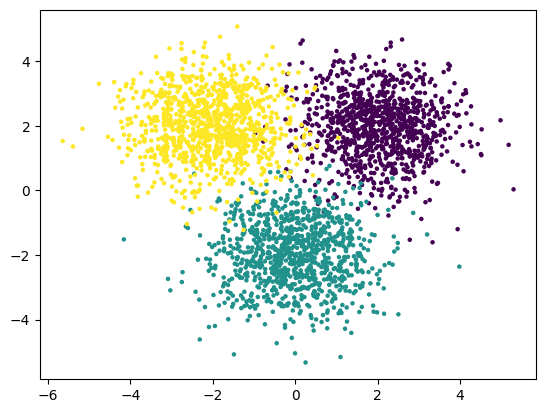

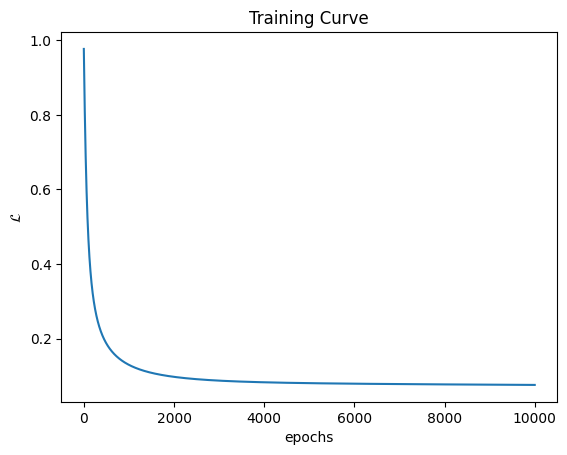

Accuracy:  0.9723333333333334
{1: array([[-0.35674527, -1.04202839, -0.59246977, -2.46216121,  1.53163019,
         0.01581792],
       [ 1.26331594, -0.30451946,  0.59553259, -0.46496434,  0.72335181,
         1.31058038]]), 2: array([[ 1.91138313, -0.12213035,  1.36807293],
       [-2.95985373,  1.28919837, -0.16940166],
       [-2.46289384, -2.72712062,  0.10502498],
       [-0.11595904, -0.98898667,  0.14335912],
       [ 0.95723385, -0.48581922, -0.73774808],
       [ 1.0726079 , -1.73957106,  0.71891238]])}
{1: array([ 0.72296271,  1.11387541, -0.72148647, -0.02015804, -0.5451778 ,
       -0.62080639]), 2: array([-0.44713542, -1.13143175, -0.44187228])}


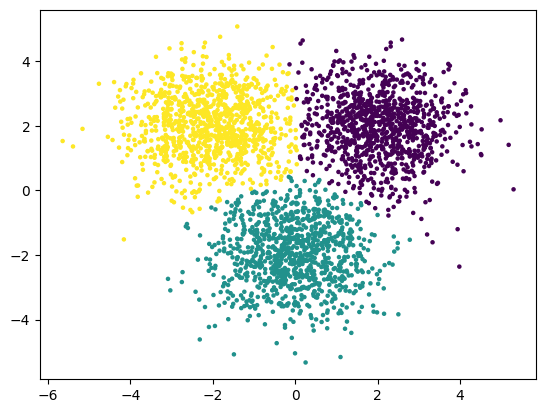

In [32]:
if __name__ == "__main__":
    main()

In [53]:
import math
class Solution:
    def convertToBase7(self, num: int) -> str:
        if num < 0:
            sign = -1
            num = -num
        else:
            sign = 1
        am = int(math.log(num)/math.log(7))
        base_7 = ''
        rem = num
        for i in range(am,0,-1):
            val = int(rem/(7**i))            
            print(i, rem, val)
            base_7 += str(val)
            rem -= val*7**i

        return sign * base_7
        

In [52]:
s= Solution()
s.convertToBase7(-7)

1 7 1
0 0 0


''